# Hangover — a quantitative teardown 🔬
### Base-rate vs conditional accuracy · Wilson intervals and Fisher tests on every cell · the exposure illusion · the decay you can't prove

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Predicts the year?: Not supported](https://img.shields.io/badge/Predicts_the_year%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We score the January Barometer the only honest way — against the base rate, with error bars sized for 76 years of data — on the S&P 500, 1950–2025.

> ⚠️ **Not investment advice.** S&P 500 (^GSPC) monthly **price return** (Yahoo, daily→month-end; no dividends — ^SP500TR only starts in 1988), 1950–2025; cash years credited the ^IRX T-bill (zero pre-1960). Sources in [`docs/references.md`](../docs/references.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (hangover/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from quantlab.repro import as_of
from hangover import data, strategy as st
ret = as_of(data.fetch_index().to_frame())["ret"]   # cache-first, pinned to the as-of; ^GSPC is price-only
tbill = data.fetch_tbill()                          # ^IRX, for the cash years (zero pre-1960)
cash = st.cash_roy(as_of(tbill.to_frame())["tbill"]) if not tbill.empty else None
tbl = st.annual_table(ret)
cm  = st.conditional_means(tbl)
bar, bh = st.barometer_returns(tbl, cash), st.buy_hold_roy(tbl)


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| Signal | **Weak** | only the down-January cell informs (+2% vs +12%; Fisher p = 0.012, permutation p = 0.002) |
| Tradability | **Mirage** | the rule just cuts equity exposure once a year; its CAGR edge is a price-only artefact |
| Predicts the year? | **Not supported** | 68% accuracy < 76% always-up base rate |

> 💡 *In plain words:* the omen's famous hit-rate is the market's hit-rate; it adds almost nothing.

## 1 · The claim, steelmanned

- **H₁:** rest-of-year mean and P(up) differ by the sign of January.
- **H₂ (the pitch):** sign(January) predicts sign(rest-of-year) better than the base rate.
- **H₃:** trading the omen beats simply holding the index.

## 2 · So what? — what rides on each

If H₂ holds, one month forecasts eleven — a free timing signal. If only a weak H₁ holds, it's a faint seasonal tic mistaken for a forecast.

## 3 · How we'd know — the protocol

Collapse months → yearly (Jan, rest-of-year) → conditional means & P(up) **with Wilson 95% intervals and a Fisher exact / permutation test on the split** (30 down-Januaries — nothing here gets claimed without a p-value) → **directional accuracy vs base rate** → tradable T-bill-after-down rule vs buy-and-hold → pre/post-1972 decay split, itself Fisher-tested.

## 4 · The teardown

### 4.1 Conditional means, intervals, and the tests

In [2]:
display(cm.round(4))
sp = st.split_tests(tbl)
print(f"P(up): {sp['k_up']}/{sp['n_up']} after an up January vs {sp['k_down']}/{sp['n_down']} after a down one")
print(f"  Fisher exact p = {sp['fisher_p']:.4f}")
print(f"rest-of-year mean gap = {sp['mean_gap']:+.2%}; permutation p = {sp['mean_perm_p']:.4f} (seeded, 20k shuffles)")

,n,roy_mean,p_up,wilson_low,wilson_high
jan_up,46.0,0.1224,0.8696,0.7433,0.9388
jan_down,30.0,0.0207,0.6000,0.4232,0.7541
unconditional,76.0,0.0823,0.7632,0.6564,0.8446


P(up): 40/46 after an up January vs 18/30 after a down one
  Fisher exact p = 0.0119
rest-of-year mean gap = +10.17%; permutation p = 0.0022 (seeded, 20k shuffles)


> 💡 *In plain words:* after a down January the year still averages **+2%** and is up **60%** of the time — the 'bad omen' is barely bad. The up-vs-down *contrast* is real (p ≈ 0.01), and **H₁ holds**. But mind the widths: the down-January cell on its own, Wilson **[42%, 75%]**, straddles the 76% base rate — with 30 observations you cannot even show that cell is below-average, only that it sits below the up-January cell.

### 4.2 The base-rate illusion, quantified

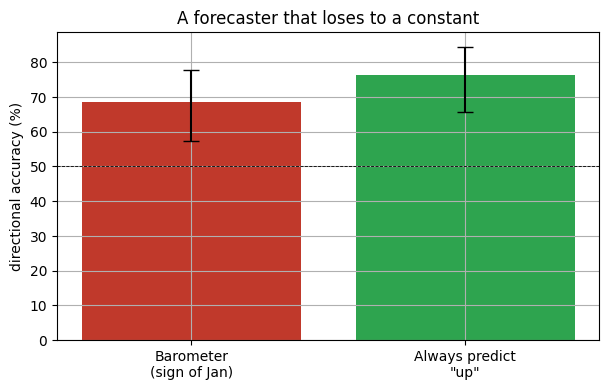

accuracy 68.4% [Wilson 57.3%, 77.8%]  vs  base rate 76.3% [Wilson 65.6%, 84.5%]


In [3]:
ac = st.accuracy_with_ci(tbl)
fig,ax=plt.subplots(figsize=(7,4))
ax.bar(['Barometer\n(sign of Jan)','Always predict\n"up"'],[ac['accuracy']*100,ac['base_rate']*100],
       yerr=[[(ac['accuracy']-ac['acc_low'])*100,(ac['base_rate']-ac['base_low'])*100],
             [(ac['acc_high']-ac['accuracy'])*100,(ac['base_high']-ac['base_rate'])*100]],
       color=['#c0392b','#2ea44f'],capsize=6)
ax.set_ylabel('directional accuracy (%)'); ax.set_title('A forecaster that loses to a constant'); ax.axhline(50,color='k',lw=.6,ls='--'); plt.show()
print(f"accuracy {ac['accuracy']:.1%} [Wilson {ac['acc_low']:.1%}, {ac['acc_high']:.1%}]  vs  base rate {ac['base_rate']:.1%} [Wilson {ac['base_low']:.1%}, {ac['base_high']:.1%}]")

> 💡 *In plain words:* if your predictor is beaten by a sticky note that says "up", it isn't a predictor. **H₂ rejected.**

### 4.3 The tradable version — it just holds less stock

In [4]:
rows={'Buy & hold (Feb-Dec)':st.summary(bh),'Barometer (T-bill if Jan down)':st.summary(bar)}
display(pd.DataFrame(rows).T[['cagr','sharpe','max_drawdown','hit_rate']].round(3))
yrs_in_cash=int((tbl['jan']<=0).sum()); print(f'years the rule sits in T-bills: {yrs_in_cash}/{len(tbl)}')

,cagr,sharpe,max_drawdown,hit_rate
Buy & hold (Feb-Dec),0.072,0.568,-0.403,0.763
Barometer (T-bill if Jan down),0.083,0.874,-0.160,0.882


years the rule sits in T-bills: 30/76


> 💡 *In plain words:* higher Sharpe, lower drawdown — bought entirely by being out of the market ~40% of years. A permanently lower equity weight (with the same T-bills) does the same. And the CAGR edge is the **tape's** doing, not the omen's: this race is price-only, and dividends (~3–4%/yr) accrue to buy-and-hold in all 76 years but to the rule only in its 46 invested ones — on a total-return tape the gap closes. **H₃ rejected.**

### 4.4 Post-publication decay — the story you can't actually test

In [5]:
dc = st.decay_split(tbl)
for lab,era in [('1950-1972','pre'),('1973-on','post')]:
    print(f"{lab}: accuracy {dc[era+'_acc']:.1%} ({dc[era+'_k']}/{dc[era+'_n']}) "
          f"[Wilson {dc[era+'_low']:.1%}, {dc[era+'_high']:.1%}], "
          f"jan-down rest-of-year {dc[era+'_down_mean']:+.2%}")
print(f"accuracy difference: Fisher exact p = {dc['fisher_p']:.3f}")

1950-1972: accuracy 78.3% (18/23) [Wilson 58.1%, 90.3%], jan-down rest-of-year -0.44%
1973-on: accuracy 64.2% (34/53) [Wilson 50.7%, 75.7%], jan-down rest-of-year +2.98%
accuracy difference: Fisher exact p = 0.288


> 💡 *In plain words:* the point estimates lean the McLean–Pontiff way — sharpest before Hirsch named it, fainter after — but 23 vs 53 years gives **Fisher p = 0.29** and almost fully overlapping intervals. The decay story is *consistent with* the data, not established by it. We say "faded" only with that caveat attached.

## 5 · The verdict

H₁ holds (weakly but significantly), H₂ and H₃ rejected → Signal `WEAK`, Tradability `MIRAGE`, the year-ahead claim `NOT SUPPORTED`.

## 6 · Could you trade it?

Only as a once-a-year de-risking switch — which is not timing, and is dominated by simply choosing your equity weight on purpose. On an honest total-return tape the rule keeps its drawdown story and loses its return story.

## 7 · Going further

Forks: (a) the "Other January Effect" (Cooper et al. 2006) on a size cross-section; (b) condition on January *magnitude* not just sign; (c) multiple-testing correction across all twelve "X-month barometers" — the calendar is full of them. Backlog: [`docs/pwb_strategies_inventory.md`](../../../docs/pwb_strategies_inventory.md).